# XAI-SOC: Final Full-Scale Computing Artefact (Model Comparison + Best-Model XAI)
### Explainable AI for SOC Alert Triage — CICIDS2017 + CSE-CIC-IDS2018

**Project:** Leveraging Explainable AI to Support Incident Response Decision-Making in Security Operations Centers
**Student ID:** 25021995

This notebook **builds directly on the Milestone 2 Initial Artefact notebook**
(data acquisition, preprocessing, and baseline Random Forest + SHAP code are
carried over and extended, not rewritten from scratch) and adds the
remaining technical scope:

1. **Both years of data** — CICIDS2017 (`chethuhn/network-intrusion-dataset`) *and* CSE-CIC-IDS2018 (`solarmainframe/ids-intrusion-csv`) are ingested and merged (Section 2–4).
2. **Multiple classical ML models** — Random Forest (from the initial artefact), Logistic Regression, Decision Tree, Histogram Gradient Boosting, XGBoost, and K-Nearest Neighbors (Section 8).
3. **A deep learning model** — a Multi-Layer Perceptron (Section 9), consistent with the MLP-based XAI literature reviewed in the MPR (Gaspar, Silva and Silva, 2024).
4. **Automatic best-model selection** (Section 10) — every model is scored on the same held-out test split; the notebook picks the strongest one for you rather than you hard-coding a choice up front.
5. **SHAP + LIME explainability on the selected best model** (Sections 11–12) — LIME did not exist in the initial artefact's code even though the MPR's Section 4 described it; it's implemented here. The explainer type (SHAP TreeExplainer vs. a general/Kernel explainer) is chosen automatically based on whether the winning model is tree-based, matching the reasoning the MPR Section 3.2 already gives for why RF pairs natively with exact SHAP.



## 0. Environment Setup

In [ ]:
# Install required packages (uncomment if running in a fresh environment, e.g. Colab)
!pip install -q kagglehub shap lime scikit-learn imbalanced-learn xgboost tensorflow pandas numpy matplotlib seaborn joblib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 14.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
##Environment Setup + Imports + Reproducibility Setup।
import os, re, glob, json, time, warnings#os=create file/folder path,re=column name matching/cleaning tool,glob=find all.CSV files,json=metadata.json/model info,
warnings.filterwarnings('ignore') #time=training time calculation,warning ignore=notebook output readable

import numpy as np
import pandas as pd        #most preprocessing handled by pd(daraframe
import matplotlib.pyplot as plt #graph,figure
import seaborn as sns #visualization tool

from sklearn.model_selection import train_test_split#70/30
from sklearn.preprocessing import StandardScaler, LabelEncoder#Numerical features bring to comparable scale & attack label text to numeric class ID
from sklearn.utils.class_weight import compute_class_weight#to reduce majority class domination>>>use on MLP
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)

import shap
import joblib #save trained model

sns.set_style('whitegrid')
RANDOM_STATE = 42    #to maintain same reproducibility.
np.random.seed(RANDOM_STATE)

print("shap version:", shap.__version__)     #just to know more about the environment.


shap version: 0.52.0


## 1. Dataset Acquisition

Both halves of the proposal's "CICIDS 2017/2018" benchmark, via KaggleHub
(the initial artefact notebook only downloaded 2017; 2018 is added here):

- **CICIDS2017**: `chethuhn/network-intrusion-dataset`
- **CSE-CIC-IDS2018**: `solarmainframe/ids-intrusion-csv`


In [ ]:
import kagglehub

path_2017 = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")
print("CICIDS2017 path:", path_2017)

path_2018 = kagglehub.dataset_download("solarmainframe/ids-intrusion-csv")
print("CSE-CIC-IDS2018 path:", path_2018)


100%|██████████| 230M/230M [00:06<00:00, 38.5MB/s]

Extracting files...


CICIDS2017 path: /root/.cache/kagglehub/datasets/chethuhn/network-intrusion-dataset/versions/1


100%|██████████| 1.60G/1.60G [00:40<00:00, 42.1MB/s]

Extracting files...


CSE-CIC-IDS2018 path: /root/.cache/kagglehub/datasets/solarmainframe/ids-intrusion-csv/versions/1


## 2. Column Harmonization Utilities

CICIDS2017 and CSE-CIC-IDS2018 are both produced by CICFlowMeter but ship
with **different column naming conventions** (e.g. ` Destination Port` vs
`Dst Port`, `Total Fwd Packets` vs `Tot Fwd Pkts`, `Init_Win_bytes_forward`
vs `Init Fwd Win Byts`). The functions below normalise both naming styles
to a canonical form so the two years can be merged into one feature matrix,
and fix a label-spelling difference (`Infilteration` vs `Infiltration`).


In [ ]:
_ABBREVIATIONS = {
    "pkts": "packets", "pkt": "packet", "fwd": "forward", "bwd": "backward",
    "len": "length", "byts": "bytes", "byte": "bytes", "tot": "total",
    "cnt": "count", "dst": "destination", "src": "source", "avg": "average",
    "std": "stddev", "var": "variance", "seg": "segment", "min": "min",
    "max": "max", "iat": "iat", "flg": "flag", "hdr": "header",
}
_MERGED_TOKEN_SPLITS = [
    (re.compile(r"totlen", re.I), "tot len"),
    (re.compile(r"pktlen", re.I), "pkt len"),
    (re.compile(r"seglen", re.I), "seg len"),
]
_STOPWORDS = {"of", "the", "and"}


def _slugify(col: str) -> str:#common standard format
    col = col.strip().lower()
    col = col.replace("/s", " persec")
    for pattern, repl in _MERGED_TOKEN_SPLITS:
        col = pattern.sub(repl, col)
    col = re.sub(r"[^a-z0-9]+", " ", col)
    tokens = [t for t in col.split() if t and t not in _STOPWORDS]
    expanded = [_ABBREVIATIONS.get(t, t) for t in tokens]
    return "_".join(sorted(expanded))


_NON_FEATURE_NAMES = ["Flow ID", "Source IP", "Destination IP", "Timestamp",
                       "Source Port", "Unnamed: 0"]
NON_FEATURE_SLUGS = {_slugify(n) for n in _NON_FEATURE_NAMES}


def build_common_columns(cols_2017, cols_2018):
    slug_to_2017, slug_to_2018 = {}, {}
    for c in cols_2017:
        s = "label" if _slugify(c) == "label" else _slugify(c)
        slug_to_2017.setdefault(s, c)
    for c in cols_2018:
        s = "label" if _slugify(c) == "label" else _slugify(c)
        slug_to_2018.setdefault(s, c)

    common = (set(slug_to_2017) & set(slug_to_2018)) - NON_FEATURE_SLUGS
    common.add("label")

    map_2017 = {slug_to_2017[s]: s for s in common if s in slug_to_2017}
    map_2018 = {slug_to_2018[s]: s for s in common if s in slug_to_2018}
    return map_2017, map_2018, common


def harmonize_label(label_series):
    fixes = {
        "infilteration": "Infiltration", "infiltration": "Infiltration",
        "web attack  brute force": "Web Attack - Brute Force",
        "web attack  xss": "Web Attack - XSS",
        "web attack  sql injection": "Web Attack - SQL Injection",
        "ftp-bruteforce": "FTP-Patator", "ftp-patator": "FTP-Patator",
        "ssh-bruteforce": "SSH-Patator", "ssh-patator": "SSH-Patator",
        "dos attacks-hulk": "DoS Hulk", "dos hulk": "DoS Hulk",
        "dos attacks-goldeneye": "DoS GoldenEye", "dos goldeneye": "DoS GoldenEye",
        "dos attacks-slowloris": "DoS Slowloris", "dos slowloris": "DoS Slowloris",
        "dos attacks-slowhttptest": "DoS Slowhttptest", "dos slowhttptest": "DoS Slowhttptest",
        "ddos attacks-loic-http": "DDoS", "ddos attack-loic-udp": "DDoS",
        "ddos attack-hoic": "DDoS", "ddos": "DDoS",
        "benign": "BENIGN", "bot": "Bot",
        "brute force -web": "Web Attack - Brute Force",
        "brute force -xss": "Web Attack - XSS",
        "sql injection": "Web Attack - SQL Injection",
        "portscan": "PortScan", "heartbleed": "Heartbleed",
    }
    def _fix(v):
        key = re.sub(r"[^a-z0-9 -]+", " ", str(v).strip().lower())
        key = re.sub(r"\s+", " ", key).strip()
        return fixes.get(key, str(v).strip())
    return label_series.map(_fix)

print("Harmonization utilities defined.")


Harmonization utilities defined.


## 3. Loading Both Years

Extends the initial artefact's Section 2 (which loaded only the 2017 daily
CSVs) to also load the 2018 daily CSVs. Set `SAMPLE_FRAC = 1.0` for the
full dataset; lower it (e.g. `0.15`, matching the initial artefact) for a
faster pass.


In [ ]:
SAMPLE_FRAC = 0.15  # 1.0 = full dataset; lower (e.g. 0.15) for a faster run

def load_dataset_dir(dir_path, sample_frac=1.0, random_state=RANDOM_STATE):
    csv_files = sorted(glob.glob(os.path.join(dir_path, "*.csv")))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in {dir_path}")
    dfs = []
    for f in csv_files:
        df_part = pd.read_csv(f, low_memory=False)
        df_part.columns = df_part.columns.str.strip()  # CICIDS headers have leading spaces
        if sample_frac < 1.0:
            df_part = df_part.sample(frac=sample_frac, random_state=random_state)
        dfs.append(df_part)
    return pd.concat(dfs, ignore_index=True)

df_2017 = load_dataset_dir(path_2017, sample_frac=SAMPLE_FRAC)
print("CICIDS2017 loaded:", df_2017.shape)

df_2018 = load_dataset_dir(path_2018, sample_frac=SAMPLE_FRAC)
print("CSE-CIC-IDS2018 loaded:", df_2018.shape)


CICIDS2017 loaded: (424611, 79)
CSE-CIC-IDS2018 loaded: (2434949, 84)


## 4. Harmonize + Merge Both Years

In [ ]:
map_2017, map_2018, common_slugs = build_common_columns(df_2017.columns, df_2018.columns)
common_cols = sorted(common_slugs)

df_2017_h = df_2017.rename(columns=map_2017)[common_cols].copy()
df_2017_h["source_year"] = 2017

df_2018_h = df_2018.rename(columns=map_2018)[common_cols].copy()
df_2018_h["source_year"] = 2018

df = pd.concat([df_2017_h, df_2018_h], ignore_index=True)
df["label"] = harmonize_label(df["label"])

print("Merged shape:", df.shape)
print("Common feature columns used by both years:", len(common_cols))


Merged shape: (2859560, 72)
Common feature columns used by both years: 71


## 5. Initial Data Overview

(Matches the initial artefact's Section 3, run here on the merged two-year data.)

label
BENIGN                        2362844
DDoS                           209247
DoS Hulk                       103846
Bot                             43336
FTP-Patator                     30207
SSH-Patator                     29196
Infiltration                    24410
PortScan                        23829
DoS Slowhttptest                21830
DoS GoldenEye                    7773
DoS Slowloris                    2531
Web Attack � Brute Force          249
Web Attack � XSS                  104
Web Attack - Brute Force           87
Web Attack - XSS                   35
Web Attack - SQL Injection         18
Label                              11
Web Attack � Sql Injection          5
Heartbleed                          2
Name: count, dtype: int64


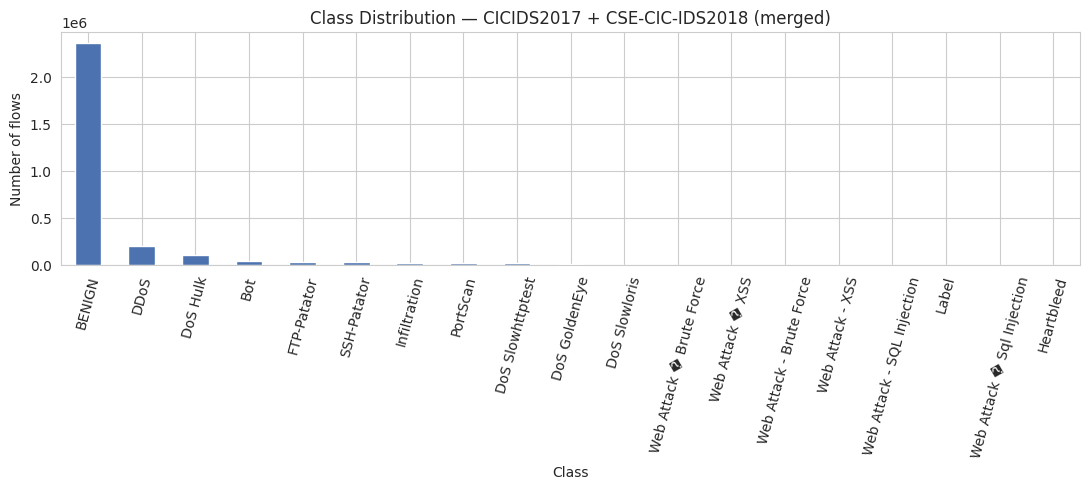

In [ ]:
print(df['label'].value_counts()) #all attack class and count

plt.figure(figsize=(11, 5))
df['label'].value_counts().plot(kind='bar', color='#4C72B0')
plt.title('Class Distribution — CICIDS2017 + CSE-CIC-IDS2018 (merged)')
plt.ylabel('Number of flows')
plt.xlabel('Class')
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
#output:severe class imbalance 82% data are benign.

## 6. Preprocessing

Identical cleaning logic to the initial artefact's Section 4 (documented in
MPR Section 4): infinite values in Flow Bytes/s and Flow Packets/s, and
duplicate flow records.


In [ ]:
print("Shape before cleaning:", df.shape)
#remove infinity values with NaN,missing row values,duplicate values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print("Shape after cleaning:", df.shape)


Shape before cleaning: (2859560, 72)
Shape after cleaning: (2385606, 72)


## 7. Split + Scale

(Matches the initial artefact's Section 4/5 split-and-scale logic.)

In [ ]:
df = df[df['label'].astype(str).str.strip().str.lower() != 'label'].copy()

feature_cols = [c for c in df.columns if c not in ['label', 'source_year']]#label and source year should be seperated.
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')#every features is converting to numeric value

df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)#if value is not numeric change it to NaN and remove it;same data processing technique on selected features only.
df = df.dropna(subset=feature_cols)

X = df[feature_cols]
feature_names = list(X.columns)#X=input Y=target
print("Number of features:", len(feature_names))  #final selected 70 features

le = LabelEncoder()
y = le.fit_transform(df['label']) #label fit+tranform ;Benign=0,Bot=1,..
print("Classes:", list(le.classes_))

# Safety net: drop any class with fewer than 2 samples so stratify can't fail
# (e.g. a rare mojibake label variant that slipped through cleaning).    ...#Safety net = code crash আটকানো। কারণ = stratified train/test split করতে সমস্যা হবে।
class_counts = pd.Series(y).value_counts()
rare_classes = class_counts[class_counts < 2].index
if len(rare_classes) > 0:
    print(f"Warning: dropping {len(rare_classes)} class(es) with <2 samples "
          f"(can't stratify): {[le.classes_[i] for i in rare_classes]}")
    keep_mask = ~pd.Series(y).isin(rare_classes).values
    X, y = X[keep_mask], y[keep_mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y   #same proportion of class data into train_split and test_split
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)#scaler.fit on training data not on testing.
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index) #avoiding data leakage.

print("Train shape:", X_train_scaled.shape, "| Test shape:", X_test_scaled.shape)
#output:fit scaler + transform on training data = transforming same scaler on testing data.
#output problem:Same attack + broken text = separate class হয়ে গেছে।Exmp:� হলো text encoding problem

Number of features: 70
Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS Slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - SQL Injection', 'Web Attack - XSS', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']
Train shape: (1669581, 70) | Test shape: (715535, 70)


## 8. Classical ML Models

The initial artefact only trained a single Random Forest. This section
trains **six classical models** on the identical train/test split so they
are directly comparable:

| Model | Notes |
|---|---|
| Random Forest | carried over from the initial artefact (Objective 2) |
| Logistic Regression | simple linear baseline |
| Decision Tree | single-tree baseline, also SHAP-TreeExplainer-compatible |
| Histogram Gradient Boosting | scikit-learn's fast native boosting implementation |
| XGBoost | boosting implementation most cited in the reviewed literature (Wali, Farrukh and Khan, 2025; Hermosilla, Berríos and Allende-Cid, 2025) |
| K-Nearest Neighbors | non-parametric baseline |

> **Scalability note:** KNN's prediction cost grows with dataset size and
> can be slow on the full ~2.8M-row merged dataset. If it's impractical on
> your hardware, comment out its entry in `MODEL_REGISTRY` below and re-run
> — everything downstream (comparison, best-model selection, explainability)
> will simply proceed without it. The same applies to any other model you
> want to skip.


In [ ]:
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)#যে class-এর data কম, তাকে বেশি importance।
class_weight_dict = dict(zip(np.unique(y_train), class_weights_arr)) #for MLP training later on.
MODEL_REGISTRY = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=None, class_weight='balanced',#can learn 300 pattern/complex pattern but overfitting problem.
        random_state=RANDOM_STATE, n_jobs=-1 #n_jobs=-1 =use maximum cpu core.
    ),
    "Logistic Regression": LogisticRegression( #traffic relationships highly nonlinear thats why performance is low
        max_iter=300, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE #max 300itr=Optimization algorithm maximum 300 iterations পর্যন্ত চেষ্টা করবে convergence-এর জন্য
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight='balanced', random_state=RANDOM_STATE #max_depth নেই,min_samples_leaf নেই,ccp_alpha নেই that might cause overfitting issue.
    ),
    "Histogram Gradient Boosting": HistGradientBoostingClassifier(#if one tree makes error,next tree focus improving previous error
        random_state=RANDOM_STATE
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),#KNN calculate distance.it will check nearest 5 attack classes when new alert comes.
}

try: #if not installed on environment
    from xgboost import XGBClassifier
    MODEL_REGISTRY["XGBoost"] = XGBClassifier(
        n_estimators=300, tree_method="hist", eval_metric="mlogloss",#hist=histogram,mlogloss=Multiclass log-loss evaluation metric
        random_state=RANDOM_STATE, n_jobs=-1
    )
except ImportError:
    print("xgboost not installed — skipping. Install with `pip install xgboost` to include it.")#no need to tense it's successfully installed

# Tree-based models (for the SHAP explainer choice in Section 11)
TREE_BASED_MODELS = {"Random Forest", "Decision Tree", "Histogram Gradient Boosting", "XGBoost"}

print("Models to train:", list(MODEL_REGISTRY.keys()))


Models to train: ['Random Forest', 'Logistic Regression', 'Decision Tree', 'Histogram Gradient Boosting', 'K-Nearest Neighbors', 'XGBoost']


In [ ]:
results = []
fitted_models = {}

for name, model in MODEL_REGISTRY.items():
    print(f"Training {name}...")
    t0 = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "model": name,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "train_time_sec": train_time,
    })
    fitted_models[name] = model
    print(f"  -> accuracy={acc:.4f}  f1_macro={f1_macro:.4f}  "
          f"f1_weighted={f1_weighted:.4f}  ({train_time:.1f}s)")

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
print("\nClassical ML results (sorted by macro F1):")
results_df


Training Random Forest...
  -> accuracy=0.9856  f1_macro=0.6999  f1_weighted=0.9840  (531.6s)
Training Logistic Regression...
  -> accuracy=0.5212  f1_macro=0.3931  f1_weighted=0.6431  (377.6s)
Training Decision Tree...
  -> accuracy=0.9811  f1_macro=0.7325  f1_weighted=0.9819  (136.8s)
Training Histogram Gradient Boosting...


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [ ]:
MODEL_REGISTRY["Histogram Gradient Boosting"] = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE,
    early_stopping=False,  # avoid an internal stratified train/val split, which

)

min_class_count = pd.Series(y_train).value_counts().min()
safe_k = min(5, max(1, min_class_count - 1))
MODEL_REGISTRY["K-Nearest Neighbors"] = KNeighborsClassifier(n_neighbors=safe_k, n_jobs=-1)
if safe_k < 5:
    print(f"Note: smallest class in X_train has only {min_class_count} sample(s); "
          f"reduced KNN's n_neighbors from 5 to {safe_k}.")

Note: smallest class in X_train has only 1 sample(s); reduced KNN's n_neighbors from 5 to 1.


In [ ]:
for name in ["Histogram Gradient Boosting", "K-Nearest Neighbors"]:
    model = MODEL_REGISTRY[name]
    print(f"Training {name}...")
    t0 = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "model": name,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "train_time_sec": train_time,
    })
    fitted_models[name] = model
    print(f"  -> accuracy={acc:.4f}  f1_macro={f1_macro:.4f}  "
          f"f1_weighted={f1_weighted:.4f}  ({train_time:.1f}s)")

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
print("\nClassical ML results (sorted by macro F1):")
results_df

Training Histogram Gradient Boosting...
  -> accuracy=0.8449  f1_macro=0.1169  f1_weighted=0.8481  (101.3s)
Training K-Nearest Neighbors...
  -> accuracy=0.9812  f1_macro=0.7394  f1_weighted=0.9812  (1.0s)

Classical ML results (sorted by macro F1):


,model,accuracy,f1_macro,f1_weighted,train_time_sec
0,K-Nearest Neighbors,0.981197,0.739441,0.981237,0.976367
1,Decision Tree,0.981115,0.732471,0.981875,136.794759
2,Random Forest,0.985553,0.699937,0.984032,531.605736
3,Logistic Regression,0.521244,0.393146,0.643070,377.594806
4,Histogram Gradient Boosting,0.844937,0.116927,0.848118,101.265207


## 9. Deep Learning Model — Multi-Layer Perceptron

A dense feedforward network, consistent with the MLP-based XAI literature
reviewed in the MPR (Gaspar, Silva and Silva, 2024 apply LIME/SHAP to an
MLP for intrusion detection). Trained with class weights to address the
same severe class imbalance discussed in MPR Sections 2.4 and 4, using
early stopping to avoid overfitting on the majority BENIGN class.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models as keras_models, callbacks

tf.random.set_seed(RANDOM_STATE)

n_features = X_train_scaled.shape[1]
n_classes = len(le.classes_)

mlp = keras_models.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

t0 = time.time()
history = mlp.fit(
    X_train_scaled.to_numpy(), y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=1024,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1,
)
mlp_train_time = time.time() - t0


Epoch 1/30
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 46s 19ms/step - accuracy: 0.3287 - loss: 3.8094 - val_accuracy: 0.1396 - val_loss: 2.2163
Epoch 2/30
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3502 - loss: 3.4478 - val_accuracy: 0.4444 - val_loss: 1.2221
Epoch 3/30
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4593 - loss: 2.6080 - val_accuracy: 0.6829 - val_loss: 1.0705
Epoch 4/30
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4887 - loss: 1.8821 - val_accuracy: 0.5208 - val_loss: 1.0943
Epoch 5/30
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4915 - loss: 1.1929 - val_accuracy: 0.3972 - val_loss: 1.1484
Epoch 6/30
1468/1468 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4916 - loss: 1.1069 - val_accuracy: 0.4162 - val_loss: 1.1908


MLP  -> accuracy=0.6819  f1_macro=0.2661  f1_weighted=0.7718  (64.6s)


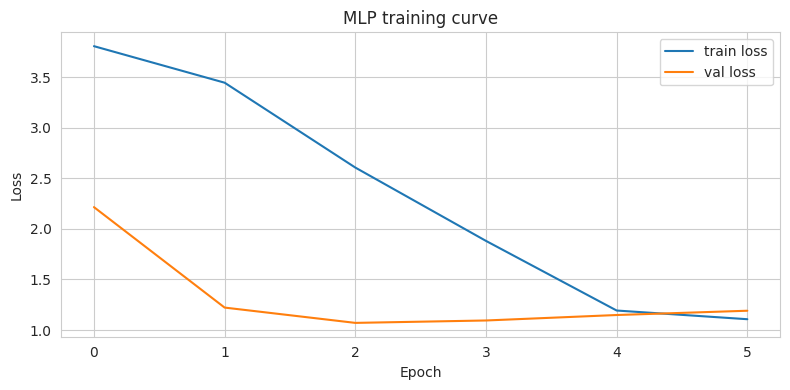

In [ ]:
mlp_pred_proba = mlp.predict(X_test_scaled.to_numpy(), verbose=0)
mlp_pred = np.argmax(mlp_pred_proba, axis=1)

mlp_acc = accuracy_score(y_test, mlp_pred)
mlp_f1_macro = f1_score(y_test, mlp_pred, average='macro')
mlp_f1_weighted = f1_score(y_test, mlp_pred, average='weighted')

print(f"MLP  -> accuracy={mlp_acc:.4f}  f1_macro={mlp_f1_macro:.4f}  "
      f"f1_weighted={mlp_f1_weighted:.4f}  ({mlp_train_time:.1f}s)")

results.append({
    "model": "MLP (Deep Learning)",
    "accuracy": mlp_acc,
    "f1_macro": mlp_f1_macro,
    "f1_weighted": mlp_f1_weighted,
    "train_time_sec": mlp_train_time,
})
fitted_models["MLP (Deep Learning)"] = mlp

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.title('MLP training curve')
plt.tight_layout()
plt.savefig('mlp_training_curve.png', dpi=150)
plt.show()


## 10. Model Comparison & Best-Model Selection

All seven models (six classical + MLP) are ranked here. **Macro F1 is used
as the primary selection metric, not raw accuracy** — consistent with
the MPR's discussion (Sections 2.4 and 4) that CICIDS' severe class
imbalance makes accuracy and weighted F1 dominated by the majority BENIGN
class, while macro F1 reflects performance on the rare attack classes that
actually matter for SOC triage.


Full model comparison (sorted by f1_macro ):


,model,accuracy,f1_macro,f1_weighted,train_time_sec
0,K-Nearest Neighbors,0.981197,0.739441,0.981237,0.976367
1,Decision Tree,0.981115,0.732471,0.981875,136.794759
2,Random Forest,0.985553,0.699937,0.984032,531.605736
3,Logistic Regression,0.521244,0.393146,0.643070,377.594806
4,MLP (Deep Learning),0.681900,0.266121,0.771755,64.571968
5,Histogram Gradient Boosting,0.844937,0.116927,0.848118,101.265207


<Figure size 1000x500 with 0 Axes>

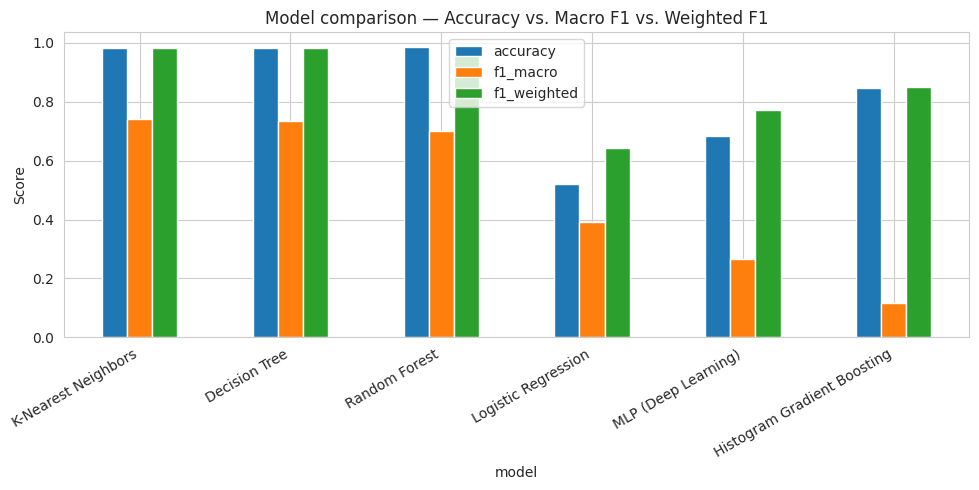


Selected best model: K-Nearest Neighbors  (macro F1 = 0.7394)


In [ ]:
SELECTION_METRIC = "f1_macro"  # change to "accuracy" or "f1_weighted" if you prefer a different criterion

full_results_df = pd.DataFrame(results).sort_values(SELECTION_METRIC, ascending=False).reset_index(drop=True)
print("Full model comparison (sorted by", SELECTION_METRIC, "):")
display(full_results_df)

plt.figure(figsize=(10, 5))
plot_df = full_results_df.set_index("model")[["accuracy", "f1_macro", "f1_weighted"]]
plot_df.plot(kind='bar', figsize=(10, 5))
plt.ylabel('Score')
plt.title('Model comparison — Accuracy vs. Macro F1 vs. Weighted F1')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

BEST_MODEL_NAME = full_results_df.iloc[0]["model"]
best_model = fitted_models[BEST_MODEL_NAME]
print(f"\nSelected best model: {BEST_MODEL_NAME}  "
      f"(macro F1 = {full_results_df.iloc[0]['f1_macro']:.4f})")


Classification report — K-Nearest Neighbors

                            precision    recall  f1-score   support

                    BENIGN       0.99      0.99      0.99    621298
                       Bot       1.00      0.99      0.99      6764
                      DDoS       1.00      1.00      1.00     46083
             DoS GoldenEye       0.98      0.99      0.98      2331
                  DoS Hulk       1.00      1.00      1.00     20013
          DoS Slowhttptest       0.92      0.88      0.90       249
             DoS Slowloris       0.98      0.99      0.99       719
               FTP-Patator       0.94      0.95      0.94       299
                Heartbleed       1.00      1.00      1.00         1
              Infiltration       0.12      0.12      0.12      6917
                  PortScan       0.94      0.95      0.95      6289
               SSH-Patator       0.99      0.99      0.99      4425
  Web Attack - Brute Force       0.52      0.68      0.59        25
We

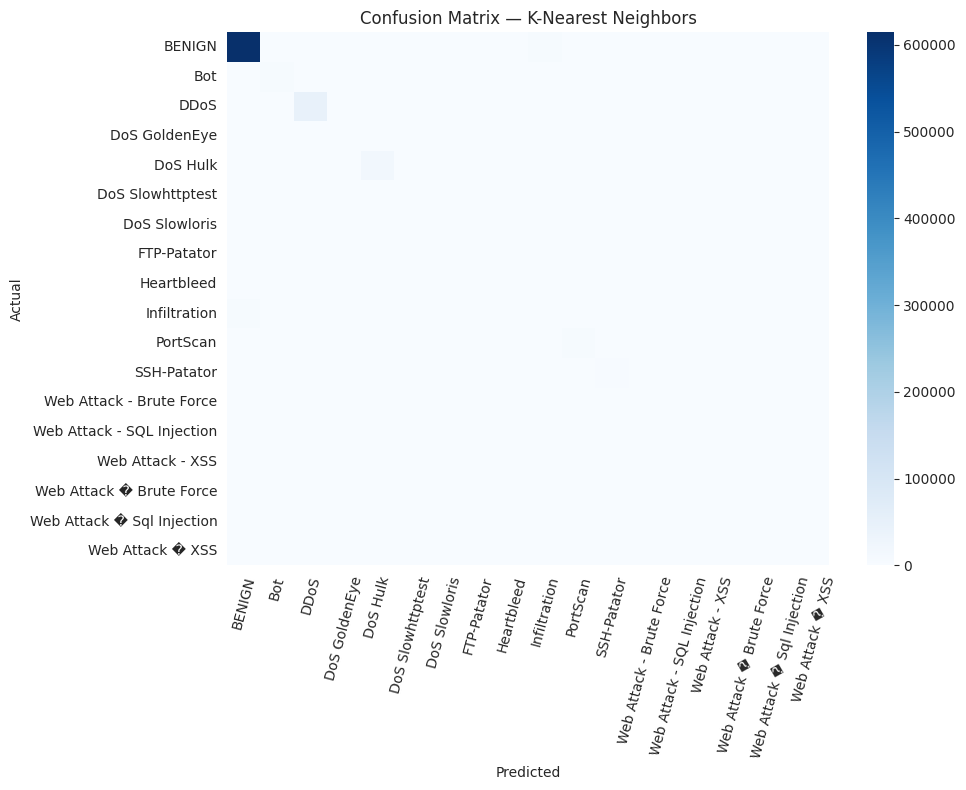

In [ ]:
# Full classification report for the selected best model
if BEST_MODEL_NAME == "MLP (Deep Learning)":
    best_y_pred = mlp_pred
else:
    best_y_pred = best_model.predict(X_test_scaled)

print(f"Classification report — {BEST_MODEL_NAME}\n")
print(classification_report(y_test, best_y_pred, target_names=le.classes_, zero_division=0))

cm = confusion_matrix(y_test, best_y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix — {BEST_MODEL_NAME}')
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig('confusion_matrix_best_model.png', dpi=150)
plt.show()


## 11. Explainability — SHAP (Global + Local) on the Best Model

The explainer is chosen automatically based on the winning model's type,
using the same reasoning my MPR Section 3.2 already sets out: tree-based
models get SHAP's exact, fast `TreeExplainer`; anything else (Logistic
Regression, KNN, or the MLP) falls back to the general-purpose `Explainer`,
which is slower and approximate — so its background/explain samples are
kept small for tractability.


In [ ]:
def make_predict_fn(model, model_name):
    """Unified predict_proba-style function for both sklearn and Keras models."""
    if model_name == "MLP (Deep Learning)":
        return lambda arr: model.predict(np.asarray(arr, dtype=float), verbose=0)
    return lambda arr: model.predict_proba(np.asarray(arr, dtype=float))


predict_fn = make_predict_fn(best_model, BEST_MODEL_NAME)
is_tree_based = BEST_MODEL_NAME in TREE_BASED_MODELS

if is_tree_based:
    print(f"{BEST_MODEL_NAME} is tree-based -> using SHAP TreeExplainer (exact, fast).")
    shap_explainer = shap.TreeExplainer(best_model)
    explain_sample = X_test_scaled.sample(n=min(300, len(X_test_scaled)), random_state=RANDOM_STATE)
    shap_exp = shap_explainer(explain_sample)
else:
    print(f"{BEST_MODEL_NAME} is NOT tree-based -> using SHAP's general Explainer "
          "(approximate; kept to a small sample for tractability).")
    background = shap.sample(X_train_scaled, 100, random_state=RANDOM_STATE)
    shap_explainer = shap.Explainer(predict_fn, background)
    explain_sample = X_test_scaled.sample(n=min(100, len(X_test_scaled)), random_state=RANDOM_STATE)
    shap_exp = shap_explainer(explain_sample)

print("SHAP values shape:", shap_exp.values.shape)


K-Nearest Neighbors is NOT tree-based -> using SHAP's general Explainer (approximate; kept to a small sample for tractability).


PermutationExplainer explainer: 101it [2:03:33, 74.13s/it]

SHAP values shape: (100, 70, 18)


In [ ]:
predict_fn = make_predict_fn(best_model, BEST_MODEL_NAME)
is_tree_based = BEST_MODEL_NAME in TREE_BASED_MODELS

if is_tree_based:
    print(f"{BEST_MODEL_NAME} is tree-based -> using SHAP TreeExplainer (exact, fast).")
    shap_explainer = shap.TreeExplainer(best_model)
    explain_sample = X_test_scaled.sample(n=min(300, len(X_test_scaled)), random_state=RANDOM_STATE)
    shap_exp = shap_explainer(explain_sample)
else:
    # KNN (and any other non-tree model) has no cheap inference path: every
    # predict_proba() call scans the full training set, and the generic
    # Permutation explainer needs ~2*n_features calls PER explained instance.
    # That's why 100 instances took 1.5+ hours. Two changes fix it:
    #   1. max_evals is pinned to the theoretical minimum (2*n_features + 1)
    #      instead of SHAP's "auto" heuristic, which scales up further for
    #      wider feature sets and was likely inflating your runtime.
    #   2. Background and explain-sample sizes are both cut down, since each
    #      one directly multiplies the number of slow predict_proba() calls.
    n_features_count = X_train_scaled.shape[1]
    max_evals = 2 * n_features_count + 1

    print(f"{BEST_MODEL_NAME} is NOT tree-based -> using SHAP's general Explainer "
          f"(approximate; max_evals capped at {max_evals}, small samples for tractability).")

    background = shap.sample(X_train_scaled, 20, random_state=RANDOM_STATE)  # was 100
    shap_explainer = shap.Explainer(predict_fn, background)
    explain_sample = X_test_scaled.sample(n=min(10, len(X_test_scaled)), random_state=RANDOM_STATE)  # was 100
    shap_exp = shap_explainer(explain_sample, max_evals=max_evals)

print("SHAP values shape:", shap_exp.values.shape)

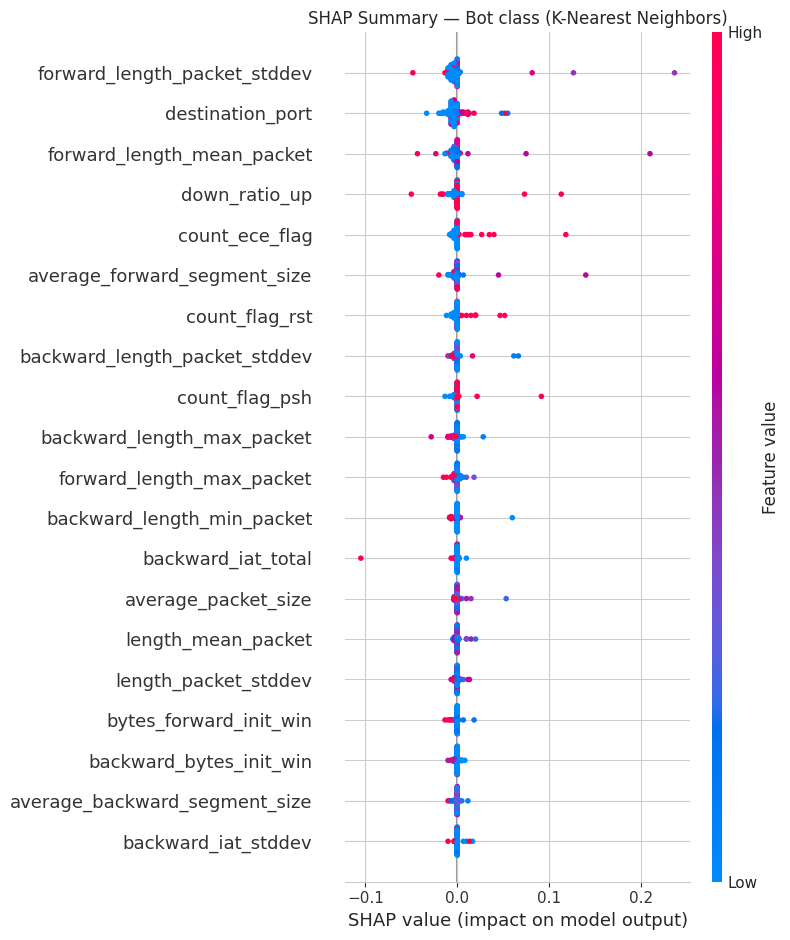

In [ ]:
attack_classes = [c for c in le.classes_ if c != 'BENIGN']
target_class_name = attack_classes[0] if attack_classes else le.classes_[0]
target_class_idx = list(le.classes_).index(target_class_name)

shap_values_for_class = (
    shap_exp.values[:, :, target_class_idx] if shap_exp.values.ndim == 3
    else shap_exp.values
)

plt.figure()
shap.summary_plot(shap_values_for_class, explain_sample, show=False)
plt.title(f'SHAP Summary — {target_class_name} class ({BEST_MODEL_NAME})')
plt.tight_layout()
plt.savefig('shap_summary_best_model.png', dpi=150, bbox_inches='tight')
plt.show()


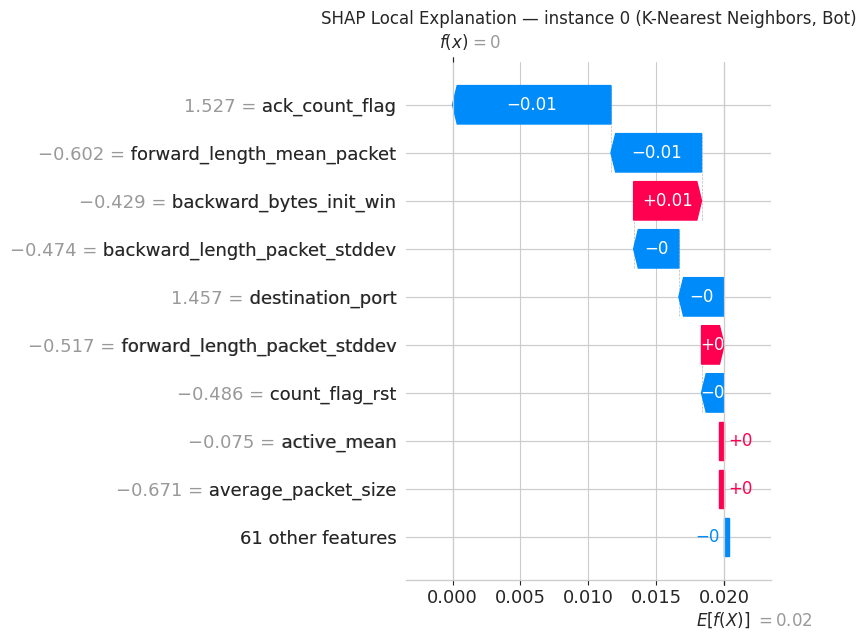

In [ ]:
instance_idx = 0
single_exp = (
    shap_exp[instance_idx, :, target_class_idx] if shap_exp.values.ndim == 3
    else shap_exp[instance_idx]
)

plt.figure()
shap.plots.waterfall(single_exp, show=False)
plt.title(f'SHAP Local Explanation — instance {instance_idx} ({BEST_MODEL_NAME}, {target_class_name})')
plt.tight_layout()
plt.savefig('shap_waterfall_best_model.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Explainability — LIME (Local) on the Best Model

**LIME did not exist in the initial artefact's code**, even though the
MPR's Section 4 described a LIME explanation being generated. It's
implemented here for the same flagged instance used for the SHAP waterfall
above (dual-explanation approach, MPR Section 3), and works identically
regardless of which model won Section 10, since it only needs a
`predict_proba`-style function.


LIME local explanation for instance 0 (model: K-Nearest Neighbors, predicted: BENIGN):

  count_flag_rst > -0.49                        +0.0103
  -0.21 < average_packet_size <= 0.23           +0.0072
  active_stddev <= -0.06                        -0.0065
  count_flag_urg <= -0.24                       +0.0061
  down_ratio_up <= -0.51                        -0.0060
  count_fin_flag <= -0.10                       +0.0054
  count_cwe_flag <= -0.01                       +0.0048
  -0.50 < destination_port <= -0.35             -0.0046
  length_max_packet > 0.40                      -0.0044
  flags_forward_urg <= -0.01                    +0.0039


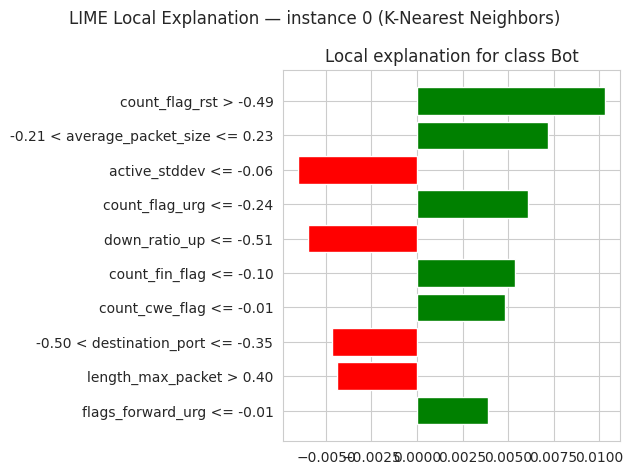

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=np.asarray(X_train_scaled),
    feature_names=feature_names,
    class_names=list(le.classes_),
    mode='classification',
    random_state=RANDOM_STATE,
    discretize_continuous=True,
)

instance_row = X_test_scaled.iloc[instance_idx]
lime_exp = lime_explainer.explain_instance(
    data_row=np.asarray(instance_row),
    predict_fn=predict_fn,
    num_features=10,
)

print(f"LIME local explanation for instance {instance_idx} "
      f"(model: {BEST_MODEL_NAME}, predicted: {le.classes_[best_y_pred[instance_idx]]}):\n")
for feature_condition, weight in lime_exp.as_list():
    print(f"  {feature_condition:45s} {weight:+.4f}")

fig = lime_exp.as_pyplot_figure()
fig.suptitle(f'LIME Local Explanation — instance {instance_idx} ({BEST_MODEL_NAME})')
plt.tight_layout()
plt.savefig('lime_local_best_model.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Sanity check: do SHAP and LIME agree on the top drivers for this alert?
shap_top = (
    pd.Series(single_exp.values, index=feature_names)
    .abs().sort_values(ascending=False).head(5)
)
lime_top = pd.Series(dict(lime_exp.as_list())).abs().sort_values(ascending=False).head(5)

print("Top-5 SHAP features (by |contribution|):")
print(shap_top)
print("\nTop-5 LIME conditions (by |weight|):")
print(lime_top)


Top-5 SHAP features (by |contribution|):
ack_count_flag                   0.011667
forward_length_mean_packet       0.006667
backward_bytes_init_win          0.005000
destination_port                 0.003333
backward_length_packet_stddev    0.003333
dtype: float64

Top-5 LIME conditions (by |weight|):
count_flag_rst > -0.49                 0.010302
-0.21 < average_packet_size <= 0.23    0.007202
active_stddev <= -0.06                 0.006510
count_flag_urg <= -0.24                0.006073
down_ratio_up <= -0.51                 0.005987
dtype: float64


## 13. Generate Backend Artifact Files

Saves everything a dashboard backend would need to load later for
**whichever model won Section 10** — no dashboard/frontend code included,
only the artifact-generation step.

- `<model_file>` — the winning trained model (`.joblib` for sklearn/XGBoost, `.keras` for the MLP)
- `scaler.joblib`, `label_encoder.joblib`
- `background_sample.csv` — raw (unscaled) rows for an "example alert" picker / explainer background
- `metadata.json` — model name/type, feature names, class list, and the full model-comparison table


In [ ]:
ARTIFACT_OUT_DIR = "artifacts"
os.makedirs(ARTIFACT_OUT_DIR, exist_ok=True)

if BEST_MODEL_NAME == "MLP (Deep Learning)":
    model_filename = "best_model_mlp.keras"
    best_model.save(os.path.join(ARTIFACT_OUT_DIR, model_filename))
else:
    model_filename = "best_model.joblib"
    joblib.dump(best_model, os.path.join(ARTIFACT_OUT_DIR, model_filename))

joblib.dump(scaler, os.path.join(ARTIFACT_OUT_DIR, "scaler.joblib"))
joblib.dump(le, os.path.join(ARTIFACT_OUT_DIR, "label_encoder.joblib"))

raw_test = df.loc[X_test.index, feature_names]
background_sample_raw = raw_test.sample(n=min(500, len(raw_test)), random_state=RANDOM_STATE)
background_sample_raw.to_csv(os.path.join(ARTIFACT_OUT_DIR, "background_sample.csv"), index=False)

best_row = full_results_df.iloc[0].to_dict()
metadata = {
    "best_model_name": BEST_MODEL_NAME,
    "best_model_file": model_filename,
    "best_model_is_tree_based": is_tree_based,
    "selection_metric": SELECTION_METRIC,
    "feature_names": feature_names,
    "classes": list(le.classes_),
    "metrics": {
        "accuracy": float(best_row["accuracy"]),
        "f1_macro": float(best_row["f1_macro"]),
        "f1_weighted": float(best_row["f1_weighted"]),
    },
    "all_models_comparison": full_results_df.to_dict(orient="records"),
    "sample_frac": SAMPLE_FRAC,
    "n_train_rows": int(X_train_scaled.shape[0]),
    "n_test_rows": int(X_test_scaled.shape[0]),
    "datasets": [
        "CICIDS2017 (chethuhn/network-intrusion-dataset)",
        "CSE-CIC-IDS2018 (solarmainframe/ids-intrusion-csv)",
    ],
}
with open(os.path.join(ARTIFACT_OUT_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)

print("Backend artifacts saved to:", ARTIFACT_OUT_DIR)
print(os.listdir(ARTIFACT_OUT_DIR))


Backend artifacts saved to: artifacts
['best_model.joblib', 'scaler.joblib', 'background_sample.csv', 'metadata.json', 'label_encoder.joblib']
